# CE6018

Tutorial 1




*   M: Earthquake_Magnitude
*   R: Rjb_km
*   Vs30: Vs30_Selected_for_analysis_m_s
*   FM: Fault_Type
*   PGA: *PGA_g*







In [ ]:
!pip install python-calamine pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 933.6/933.6 kB 19.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd

# Define the file path
file_path = '/content/drive/MyDrive/CE6018/TH/GMB1/GMN10H1PE1TMAX20.txt'

# Loading the txt file separated by space
th_df = pd.read_csv(file_path, sep='\s+', header=None)

# Rename the columns as requested
th_df.columns = ['time', 'acceleration']

# Display the first 5 rows of the DataFrame
th_df.head(3)

<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-2071401854.py:7: SyntaxWarning: invalid escape sequence '\s'
  th_df = pd.read_csv(file_path, sep='\s+', header=None)


,time,acceleration
0,0.00,-0.000021
1,0.02,-0.000020
2,0.04,-0.000020


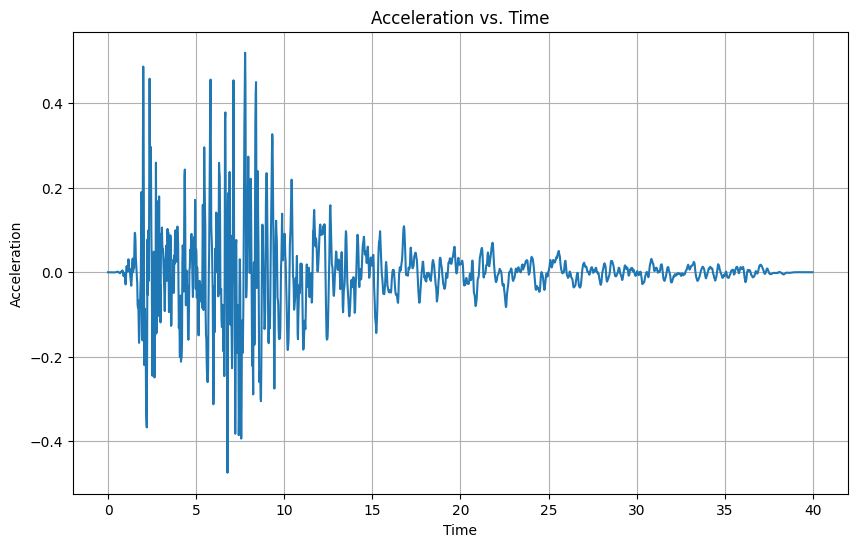

In [ ]:
import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(th_df['time'], th_df['acceleration'])

# Add labels and title
plt.xlabel('Time')
plt.ylabel('Acceleration')
plt.title('Acceleration vs. Time')
plt.grid(True)

# Display the plot
plt.show()

In [ ]:
import pandas as pd
import time

flat_filepath = "/content/drive/MyDrive/CE6018/FlatFiles/NGAsub_MegaFlatfile_RotD50_050_R211022_public.xlsx"

# Define the columns to load
selected_columns = [
    'Earthquake_Magnitude',
    'Rjb_km',
    'Vs30_Selected_for_Analysis_m_s',
    'Fault_Type',
    'PGA_g'
]

# Load the specified columns from the Excel file using the 'calamine' engine for efficiency
try:
    flat_df = pd.read_excel(flat_filepath, engine='calamine', usecols=selected_columns)
    print(f"Successfully loaded {len(selected_columns)} columns from the Excel file.")
    display(flat_df.head())
    print(f"Shape of the loaded DataFrame: {flat_df.shape}")
except Exception as e:
    print(f"An error occurred while loading the Excel file: {e}")
    print("Please ensure the column names are exactly as they appear in the Excel file and that the file is accessible.")


Successfully loaded 5 columns from the Excel file.


,Earthquake_Magnitude,Fault_Type,Rjb_km,Vs30_Selected_for_Analysis_m_s,PGA_g
0,7.96,0,1650.425991,750.0,0.000051
1,7.96,0,407.259911,635.0,0.002596
2,7.96,0,1658.439810,455.0,0.000138
3,7.96,0,1398.260494,750.0,0.000573
4,7.96,0,1155.785064,455.0,0.001979


Shape of the loaded DataFrame: (71340, 5)


In [ ]:
(flat_df.columns)

Index(['Earthquake_Magnitude', 'Fault_Type', 'Rjb_km',
       'Vs30_Selected_for_Analysis_m_s', 'PGA_g'],
      dtype='object')

In [ ]:
len(flat_df)

71340

In [ ]:
print(f"Original DataFrame shape: {flat_df.shape}")

# Filter 1: Earthquake_Magnitude >= 4
filtered_df = flat_df[flat_df['Earthquake_Magnitude'] >= 4]
print(f"Shape after filtering Earthquake_Magnitude >= 4: {filtered_df.shape}")

# Filter 2: Rjb_km >= 0 and Rjb_km <= 500
filtered_df = filtered_df[(filtered_df['Rjb_km'] >= 0) & (filtered_df['Rjb_km'] <= 500)]
print(f"Shape after filtering 0 <= Rjb_km <= 500: {filtered_df.shape}")

# Filter 3: Remove rows with any column value < 0
# This creates a boolean DataFrame where True means value < 0
negative_values_mask = (filtered_df < 0).any(axis=1)

# Invert the mask to keep rows where NO value is < 0
filtered_df = filtered_df[~negative_values_mask]
print(f"Shape after removing rows with any value < 0: {filtered_df.shape}")

print("\nFirst 5 rows of the filtered DataFrame:")
display(filtered_df.head())

print(f"Total rows removed: {flat_df.shape[0] - filtered_df.shape[0]}")

Original DataFrame shape: (71340, 5)
Shape after filtering Earthquake_Magnitude >= 4: (68473, 5)
Shape after filtering 0 <= Rjb_km <= 500: (55395, 5)
Shape after removing rows with any value < 0: (54173, 5)

First 5 rows of the filtered DataFrame:


,Earthquake_Magnitude,Fault_Type,Rjb_km,Vs30_Selected_for_Analysis_m_s,PGA_g
1,7.96,0,407.259911,635.0,0.002596
39,7.28,0,196.542941,635.0,0.029509
51,7.28,0,380.016398,635.0,0.003335
60,7.00,2,71.953781,635.0,0.013477
73,7.00,2,440.125030,635.0,0.001645


Total rows removed: 17167


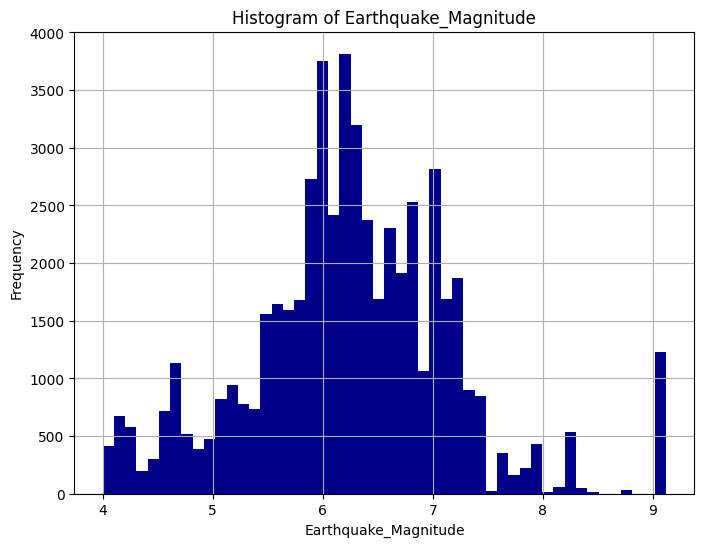

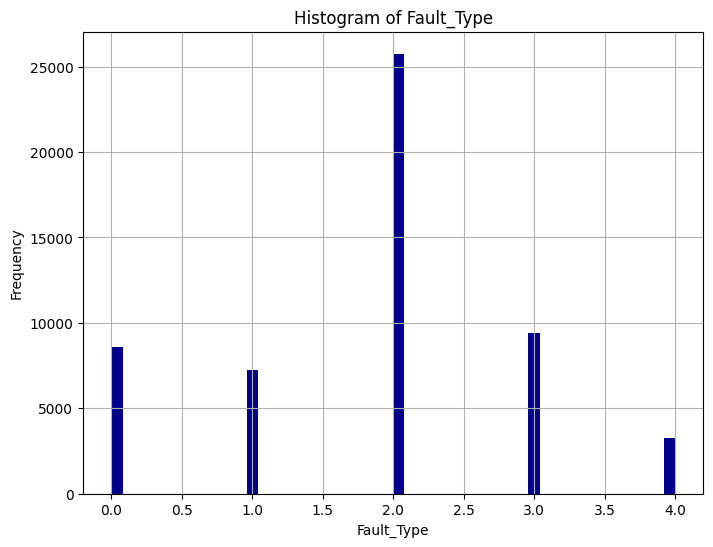

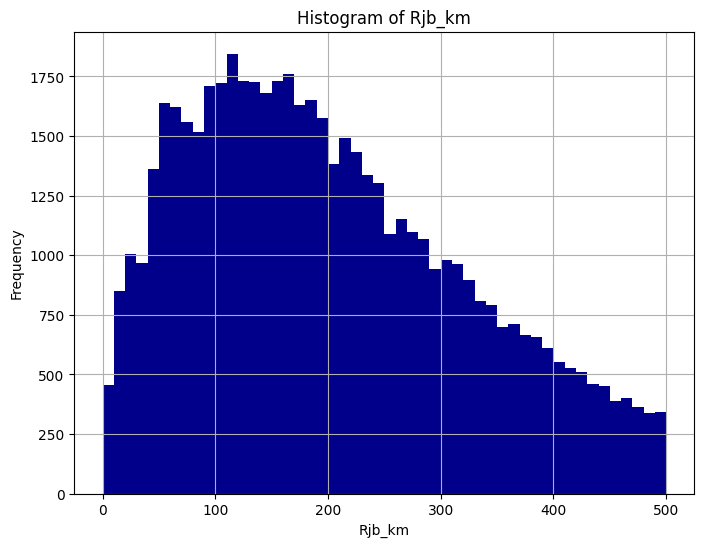

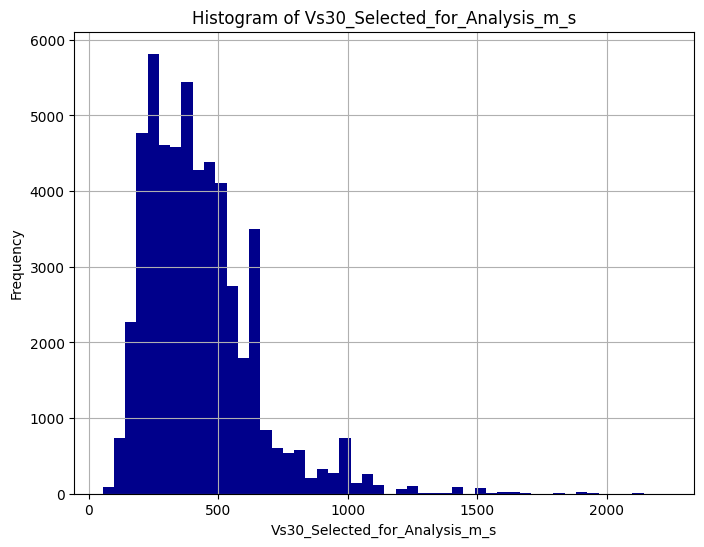

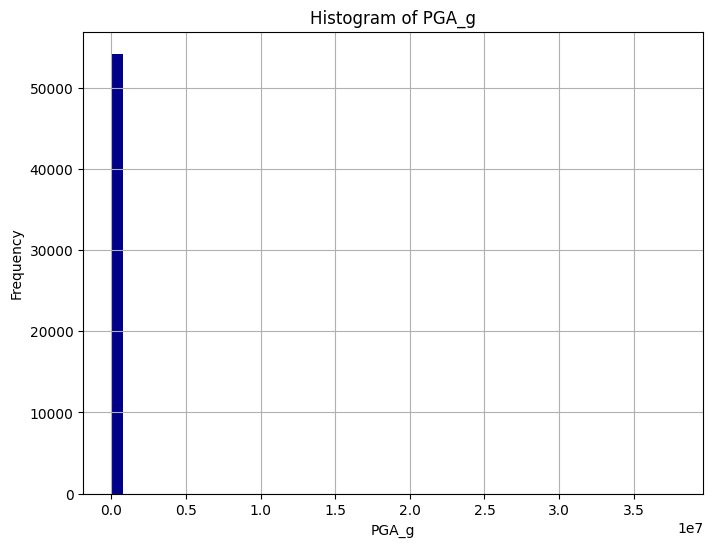

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Loop through each column and plot a histogram in a separate figure
for col in filtered_df.columns:
    # Ensure the column is numeric before plotting a histogram
    if pd.api.types.is_numeric_dtype(filtered_df[col]):
        plt.figure(figsize=(8, 6)) # Create a new figure for each histogram
        filtered_df[col].hist(bins=50, color='darkblue') # Plot with 'Dark Blue' color
        plt.title(f'Histogram of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.grid(True)

        # Save the figure locally (not in Drive)
        plt.savefig(f'{col}_histogram.png')
        plt.show()
    else:
        print(f'Skipping non-numeric column for histogram: {col}')

In [ ]:
import pandas as pd

# Loop through each column in the filtered_df
for col in filtered_df.columns:
    # Check if the column is numeric before calculating statistics
    if pd.api.types.is_numeric_dtype(filtered_df[col]):
        print(f"\n--- Statistics for column: {col} ---")
        print(f"Mean: {filtered_df[col].mean():.4f}")
        print(f"Median: {filtered_df[col].median():.4f}")
        print(f"Skewness: {filtered_df[col].skew():.4f}")
        print(f"Standard Deviation: {filtered_df[col].std():.4f}")
        print(f"Kurtosis: {filtered_df[col].kurtosis():.4f}")
    else:
        print(f"\n--- Skipping non-numeric column: {col} ---")


--- Statistics for column: Earthquake_Magnitude ---
Mean: 6.2481
Median: 6.2500
Skewness: 0.2744
Standard Deviation: 0.9429
Kurtosis: 0.9797

--- Statistics for column: Fault_Type ---
Mean: 1.8432
Median: 2.0000
Skewness: -0.1620
Standard Deviation: 1.0740
Kurtosis: -0.3723

--- Statistics for column: Rjb_km ---
Mean: 201.7944
Median: 183.3370
Skewness: 0.4942
Standard Deviation: 120.9827
Kurtosis: -0.6114

--- Statistics for column: Vs30_Selected_for_Analysis_m_s ---
Mean: 428.4766
Median: 390.0000
Skewness: 1.6457
Standard Deviation: 213.5084
Kurtosis: 5.0890

--- Statistics for column: PGA_g ---
Mean: 2328.8633
Median: 0.0075
Skewness: 134.4382
Standard Deviation: 242968.9881
Kurtosis: 19498.9253


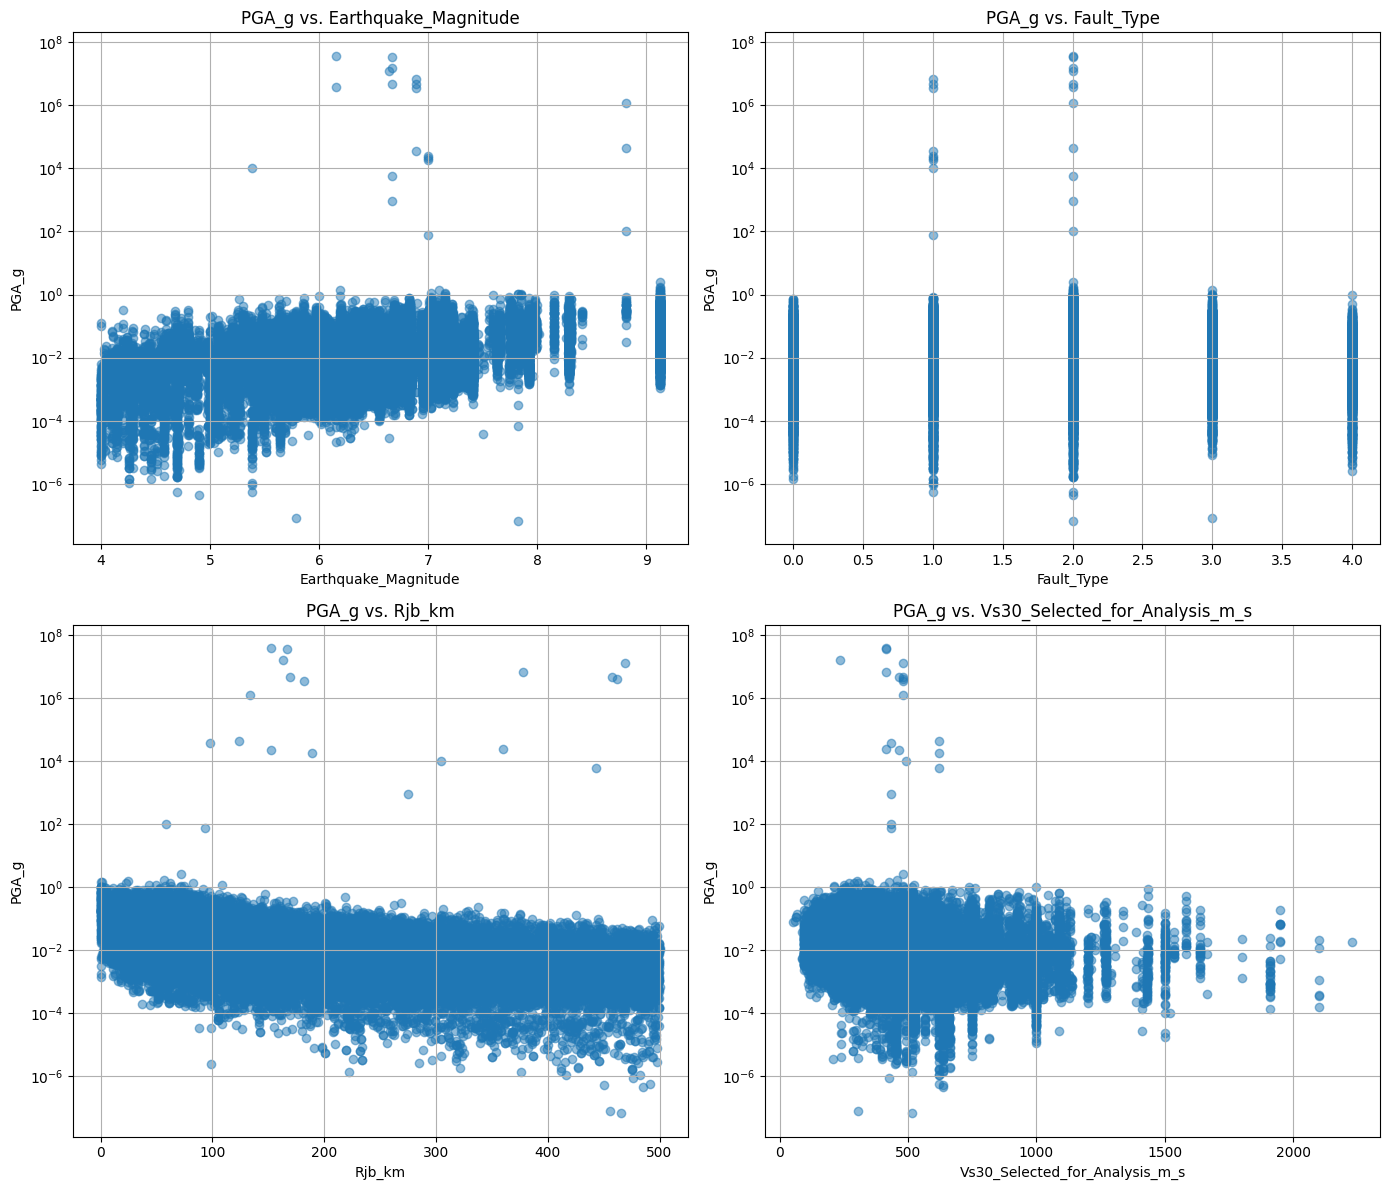

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Define the target column
target_column = 'PGA_g'

# Get all other columns that are numeric, excluding the target column itself
other_numeric_columns = [col for col in filtered_df.columns
                         if col != target_column and pd.api.types.is_numeric_dtype(filtered_df[col])]

# Get the number of subplots needed
num_plots = len(other_numeric_columns)

# Calculate a suitable grid size for the subplots
num_cols_per_row = 2 # You can adjust this value
num_rows = (num_plots + num_cols_per_row - 1) // num_cols_per_row

# Create a figure and a set of subplots
fig, axes = plt.subplots(num_rows, num_cols_per_row, figsize=(num_cols_per_row * 7, num_rows * 6))
axes = axes.flatten() # Flatten the axes array for easy iteration

# Loop through each 'other_column' and create a scatter plot against 'PGA_g'
for i, col in enumerate(other_numeric_columns):
    ax = axes[i]
    ax.scatter(filtered_df[col], filtered_df[target_column], alpha=0.5)
    ax.set_title(f'{target_column} vs. {col}')
    ax.set_xlabel(col)
    ax.set_ylabel(target_column)
    ax.set_yscale('log')
    ax.grid(True)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout() # Adjust subplot parameters for a tight layout
plt.show()

# Tutorial 2